In [2]:
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib inline

In [19]:
# load in the Playground Equipment data file
data = pd.read_csv("https://data.wprdc.org/datastore/dump/e39ef76e-0a11-47c8-a86f-a37f55db7a2b")

# look at the first ten rows of the data
data.sample(10)

,_id,id,name,equipment_type,manufacturer,safety_surface_type,ada_accessible,street_number,street,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
27,28,327771001,Lewis Playground,Swing 4 Bays,Playworld,SofSurfaces,t,NaN,Chatsworth Ave,Hazelwood,5,15,42003562900,3,15,4,2-13,40.412928,-79.944621
276,277,688467713,Vanucci Playground,Swing 2 Bays,Little Tykes,SofSurfaces,t,1251.0,Westfield St,Beechview,4,19,42003191600,5,19,6,4-28,40.414704,-80.019103
116,117,679746593,Schenley Bartlett Playground,Swing 3 Bays,Playworld,SofSurfaces,t,NaN,Bartlett Rd,Squirrel Hill South,5,14,42003980500,3,14,4,2-8,40.433455,-79.935622
286,287,1849410074,Westinghouse Playground,Play Area 5 to 12,Little Tykes,SofSurfaces,f,398.0,N Murtland St,Point Breeze North,9,14,42003140500,2,14,4,3-14,40.452937,-79.903125
191,192,1185311965,East Carnegie Playground,Swing 2 Bays,Little Tykes,SofSurfaces,t,NaN,Doolittle St,East Carnegie,2,28,42003562800,5,28,6,1-19,40.414672,-80.074945
245,246,251472869,Arsenal Playground,Swing 4 Bays,Little Tykes,SofSurfaces,t,253.0,39th St,Lower Lawrenceville,7,6,42003060300,2,6,2,3-3,40.466720,-79.961524
170,171,1927765426,Brighton Heights Playground,Play Area 5 to 12,Little Tykes,Pour in Place,f,NaN,Weitz Way,Brighton Heights,1,27,42003270800,1,27,1,1-14,40.486666,-80.031899
379,380,1040595934,Schenley Oval Playground,Slide,Little Tykes,SofSurfaces,f,NaN,Overlook Dr,Squirrel Hill South,5,14,42003980500,3,14,4,2-8,40.431167,-79.944979
405,630,2017890070,Townsend Playground,Play Area 5 to 12,Playworld,SofSurfaces,f,817.0,Chartiers Ave,Elliott,2,20,42003562600,5,20,6,1-17,40.443044,-80.040063
97,98,1118649743,Highland Park Super Playground,Swing 1 Bay,NaN,Engineered Wood Fiber,f,NaN,Reservoir Dr,Highland Park,7,11,42003980100,2,11,5,3-9,40.480311,-79.918158


In [10]:
data.shape

(445, 19)

In [5]:
data.isnull().sum()

_id                        0
id                         0
name                       0
equipment_type             0
manufacturer              32
safety_surface_type       48
ada_accessible             0
street_number            151
street                    10
neighborhood               0
council_district           0
ward                       0
tract                      0
public_works_division      0
pli_division               0
police_zone                0
fire_zone                  0
latitude                   0
longitude                  0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   _id                    445 non-null    int64  
 1   id                     445 non-null    int64  
 2   name                   445 non-null    object 
 3   equipment_type         445 non-null    object 
 4   manufacturer           413 non-null    object 
 5   safety_surface_type    397 non-null    object 
 6   ada_accessible         445 non-null    object 
 7   street_number          294 non-null    float64
 8   street                 435 non-null    object 
 9   neighborhood           445 non-null    object 
 10  council_district       445 non-null    int64  
 11  ward                   445 non-null    int64  
 12  tract                  445 non-null    int64  
 13  public_works_division  445 non-null    int64  
 14  pli_division           445 non-null    int64  
 15  police

In [7]:
data.describe()

,_id,id,street_number,council_district,ward,tract,public_works_division,pli_division,police_zone,latitude,longitude
count,445.000000,4.450000e+02,294.000000,445.000000,445.000000,4.450000e+02,445.000000,445.000000,445.000000,445.000000,445.000000
mean,254.896629,1.032533e+09,1770.986395,4.613483,16.903371,4.200332e+10,3.017978,16.903371,3.761798,40.441818,-79.975157
std,190.269044,6.273860e+08,1992.430844,2.555474,7.423612,2.782056e+05,1.417281,7.423612,1.682415,0.025324,0.050281
min,1.000000,1.772581e+06,1.000000,1.000000,1.000000,4.200301e+10,1.000000,1.000000,1.000000,40.369791,-80.080308
25%,112.000000,4.633404e+08,346.500000,2.000000,11.000000,4.200312e+10,2.000000,11.000000,2.000000,40.424612,-80.017814
50%,223.000000,1.022980e+09,855.000000,5.000000,16.000000,4.200320e+10,3.000000,16.000000,4.000000,40.443375,-79.974074
75%,334.000000,1.563586e+09,2300.500000,6.000000,22.000000,4.200356e+10,5.000000,22.000000,5.000000,40.460678,-79.928245
max,762.000000,2.141071e+09,7614.000000,9.000000,32.000000,4.200398e+10,6.000000,32.000000,6.000000,40.486761,-79.889456


In [12]:
data["ada_accessible"].value_counts().sort_values()

ada_accessible
t     95
f    350
Name: count, dtype: int64

In [14]:
# which neighborhoods have playground equipment that is ADA accessible?
ada_mask = data["ada_accessible"] == "t"
ada_mask.head(20)

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15     True
16    False
17    False
18     True
19    False
Name: ada_accessible, dtype: bool

In [16]:
ada = data[ada_mask]
ada["neighborhood"].head()

3     Squirrel Hill South
6                 Windgap
10            Perry South
15        Crafton Heights
18               Fineview
Name: neighborhood, dtype: object

In [26]:
# how many of each equipment type does each neighborhood have?
data[["equipment_type", "neighborhood"]].value_counts()

equipment_type     neighborhood            
Slide              Squirrel Hill South         6
Swing 2 Bays       East Liberty                5
Play Area 5 to 12  Squirrel Hill South         5
                   Beechview                   5
Swing 3 Bays       Squirrel Hill South         5
                                              ..
Play Area 2 to 12  Fineview                    1
                   Greenfield                  1
                   Hazelwood                   1
                   Highland Park               1
                   Lincoln-Lemington-Belmar    1
Name: count, Length: 317, dtype: int64

/scratch/slurm-34805/ipykernel_1141669/1840762777.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


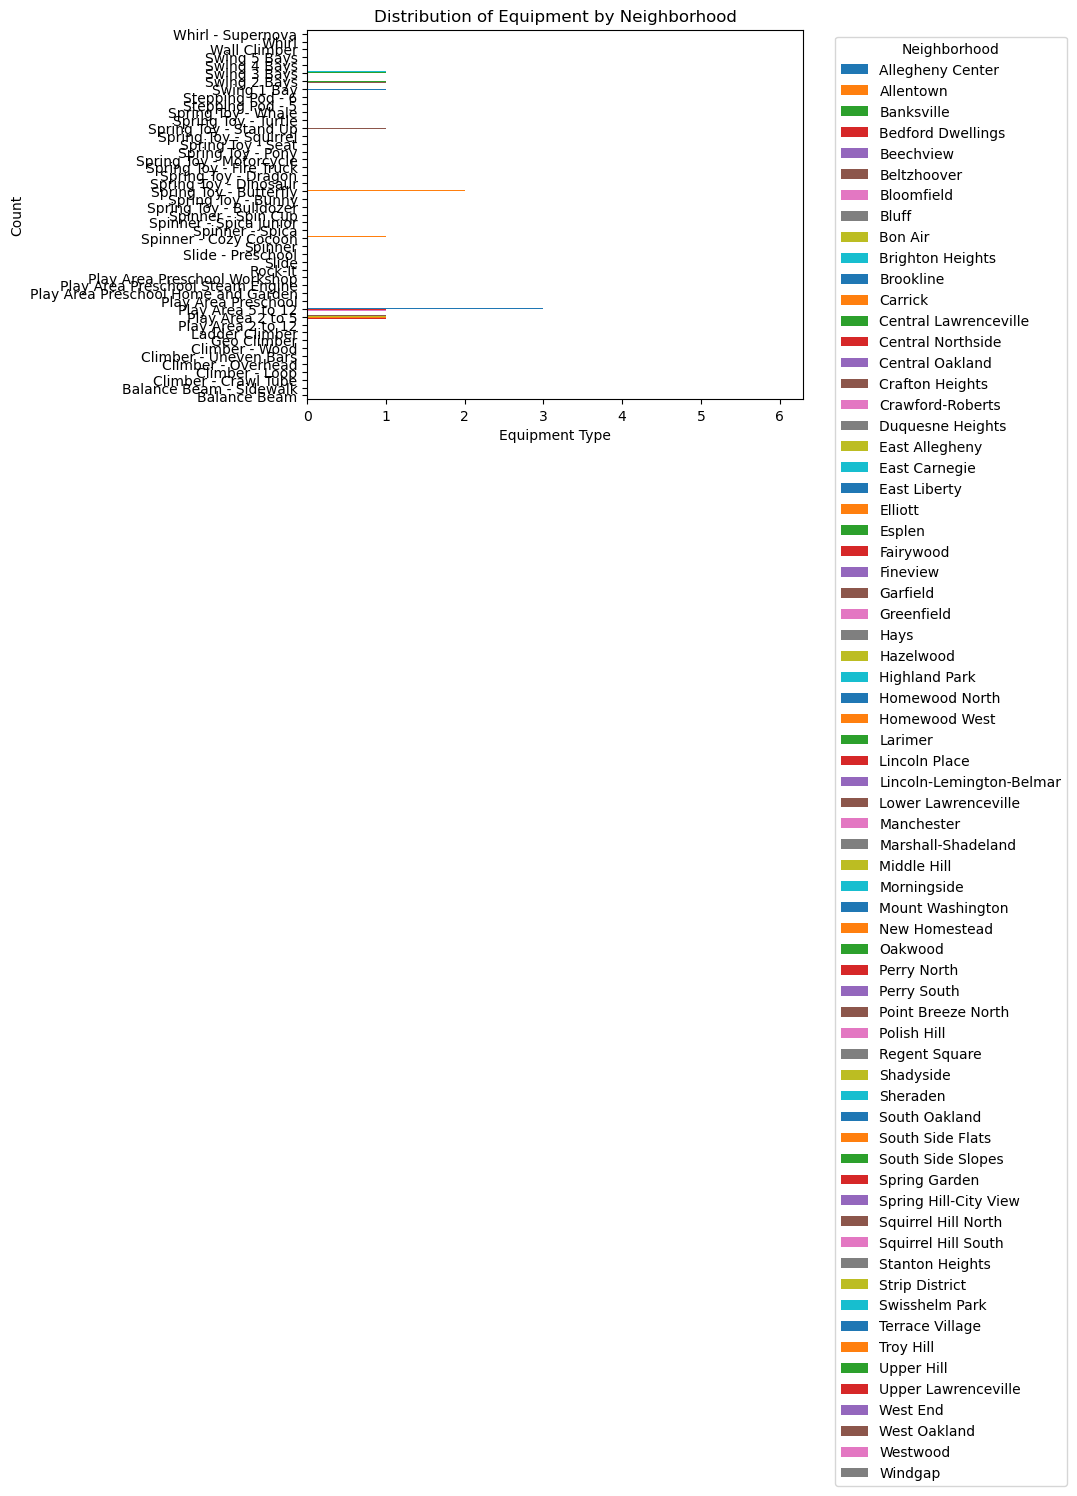

In [31]:
counts = data[["equipment_type", "neighborhood"]].value_counts().unstack()

# Plot (kind='bar' for grouped, add stacked=True for a stacked bar)
counts.plot(kind='barh')

# Formatting
plt.title("Distribution of Equipment by Neighborhood")
plt.xlabel("Equipment Type")
plt.ylabel("Count")
plt.legend(title="Neighborhood", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
data["safety_surface_type"].unique

array(['Pour in Place', 'SofSurfaces', 'Greenpark Breakfall', 'Tiles',
       'Engineered Wood Fiber', nan], dtype=object)